# Lab 3. Documents as Vectors

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-03-documents-as-vectors.ipynb)

This lab accompanies Chapter 3 of **Mathematical Natural Language Processing**.

In Lab 1, we saw the full NLP pipeline.  In Lab 2, we studied tokenization and vocabularies.  Now we study the next mathematical step:

$$
\text{token sequence} \longrightarrow \text{document vector} \longrightarrow \text{matrix computation}.
$$

The central question is:

> How can a collection of text documents be represented as vectors so that linear algebra can compare, search, and organize them?

This notebook builds count vectors, binary vectors, relative-frequency vectors, TF-IDF vectors, cosine similarity search, stop-word projections, and a small SVD document map from scratch.

## How to use this lab

This notebook is designed for independent study.

1. Read the explanation before each code block.
2. Run the code cells in order.
3. Inspect the printed tables and plots.
4. Modify the corpus and queries when you see **Try it yourself**.
5. Complete the exercises and mini-project at the end.

The lab intentionally avoids large NLP libraries.  We use `numpy`, `pandas`, and `matplotlib` so the mathematical objects remain visible.

## Learning goals

After completing this lab, you should be able to:

- define a document-vector representation as a map $\phi:V^* \to R^d$;
- build a vocabulary from a tokenized corpus;
- construct a document-term matrix $X \in R^{n \times d}$;
- distinguish count, binary, relative-frequency, and normalized representations;
- compute cosine similarity between documents and queries;
- explain why raw counts may favor long documents;
- compute document frequency, inverse document frequency, and TF-IDF weights;
- compare count-based search with TF-IDF search;
- interpret stop-word removal as a coordinate projection;
- visualize document geometry using singular value decomposition;
- evaluate a tiny search engine using precision at $k$.

## 1. Mathematical background: document-vector maps

Let $V=\{v_1,v_2,\ldots,v_d\}$ be a finite vocabulary.  A tokenized document is a finite sequence

$$
x=(t_1,t_2,\ldots,t_m), \qquad t_i \in V.
$$

A document-vector representation is a map

$$
\phi:V^* \to R^d.
$$

The coordinate $\phi_j(x)$ measures how strongly token $v_j$ appears in the document.  Different choices of $\phi$ produce different models:

$$
\phi_j(x) = \text{count of }v_j,
$$

$$
\phi_j(x) = 1 \text{ if }v_j\text{ appears, and }0\text{ otherwise},
$$

or

$$
\phi_j(x) = \text{TF-IDF weight of }v_j\text{ in }x.
$$

For a corpus of $n$ documents, we arrange all document vectors as rows of a matrix

$$
X \in R^{n \times d}.
$$

This is the **document-term matrix**.  Row $i$ represents document $i$, and column $j$ represents vocabulary token $v_j$.

## 2. Setup

We import standard tools for text processing, arrays, tables, and plots.

In [1]:
import re
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 30)

## 3. A small mathematical NLP corpus

We use a small corpus so every vector can be inspected.  The corpus contains documents about language models, vectors, probability, optimization, graphs, and retrieval.

In a real application, the corpus may contain thousands or millions of documents.  The same ideas apply, but the matrices become much larger and are usually stored sparsely.

In [2]:
documents = [
    "Language models assign probabilities to token sequences.",
    "A document vector stores counts of vocabulary tokens.",
    "Cosine similarity compares documents by the angle between vectors.",
    "TF-IDF gives more weight to terms that are specific to a document.",
    "Probability models estimate the chance of the next word.",
    "Optimization trains neural networks by minimizing a loss function.",
    "Graph methods represent words and documents as nodes connected by edges.",
    "Retrieval systems rank documents in response to a user query.",
    "A matrix can store all document vectors in its rows.",
    "Stop words such as the and of often carry little topical information.",
    "Embeddings map words or documents into a geometric vector space.",
    "A search engine uses vector similarity to find relevant text."
]

doc_ids = [f"D{i+1}" for i in range(len(documents))]
corpus_table = pd.DataFrame({"doc_id": doc_ids, "text": documents})
corpus_table

,doc_id,text
0,D1,Language models assign probabilities to token sequences.
1,D2,A document vector stores counts of vocabulary tokens.
2,D3,Cosine similarity compares documents by the angle between vectors.
3,D4,TF-IDF gives more weight to terms that are specific to a document.
4,D5,Probability models estimate the chance of the next word.
5,D6,Optimization trains neural networks by minimizing a loss function.
6,D7,Graph methods represent words and documents as nodes connected by edges.
7,D8,Retrieval systems rank documents in response to a user query.
8,D9,A matrix can store all document vectors in its rows.
9,D10,Stop words such as the and of often carry little topical information.


## 4. Tokenization for this lab

We use a simple tokenizer:

1. lowercase the text;
2. keep alphabetic tokens and contractions made from letters;
3. remove punctuation;
4. return a list of tokens.

This tokenizer is not perfect, but it is enough for studying document vectors.  In practical NLP, tokenization choices can strongly affect the representation.

In [3]:
def tokenize(text):
    """A small word tokenizer for the lab corpus."""
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

tokenized_documents = [tokenize(doc) for doc in documents]

for doc_id, tokens in zip(doc_ids, tokenized_documents):
    print(f"{doc_id}:", tokens)

D1: ['language', 'models', 'assign', 'probabilities', 'to', 'token', 'sequences']
D2: ['a', 'document', 'vector', 'stores', 'counts', 'of', 'vocabulary', 'tokens']
D3: ['cosine', 'similarity', 'compares', 'documents', 'by', 'the', 'angle', 'between', 'vectors']
D4: ['tf', 'idf', 'gives', 'more', 'weight', 'to', 'terms', 'that', 'are', 'specific', 'to', 'a', 'document']
D5: ['probability', 'models', 'estimate', 'the', 'chance', 'of', 'the', 'next', 'word']
D6: ['optimization', 'trains', 'neural', 'networks', 'by', 'minimizing', 'a', 'loss', 'function']
D7: ['graph', 'methods', 'represent', 'words', 'and', 'documents', 'as', 'nodes', 'connected', 'by', 'edges']
D8: ['retrieval', 'systems', 'rank', 'documents', 'in', 'response', 'to', 'a', 'user', 'query']
D9: ['a', 'matrix', 'can', 'store', 'all', 'document', 'vectors', 'in', 'its', 'rows']
D10: ['stop', 'words', 'such', 'as', 'the', 'and', 'of', 'often', 'carry', 'little', 'topical', 'information']
D11: ['embeddings', 'map', 'words', 'o

## 5. Build the vocabulary

The vocabulary is the set of tokens used as vector coordinates.  We sort tokens first by decreasing frequency, then alphabetically for reproducibility.

Let

$$
V = (v_1,v_2,\ldots,v_d).
$$

The vocabulary order determines the coordinate order of every document vector.

In [4]:
token_counts = Counter(token for doc in tokenized_documents for token in doc)

vocabulary = sorted(token_counts, key=lambda w: (-token_counts[w], w))
token_to_index = {token: j for j, token in enumerate(vocabulary)}
index_to_token = {j: token for token, j in token_to_index.items()}

print("Vocabulary size d =", len(vocabulary))
print("First 25 vocabulary tokens:")
print(vocabulary[:25])

freq_table = pd.DataFrame({
    "token": vocabulary,
    "count": [token_counts[t] for t in vocabulary]
})
freq_table.head(20)

Vocabulary size d = 86
First 25 vocabulary tokens:
['a', 'to', 'documents', 'the', 'by', 'document', 'of', 'vector', 'words', 'and', 'as', 'in', 'models', 'similarity', 'vectors', 'all', 'angle', 'are', 'assign', 'between', 'can', 'carry', 'chance', 'compares', 'connected']


,token,count
0,a,7
1,to,5
2,documents,4
3,the,4
4,by,3
5,document,3
6,of,3
7,vector,3
8,words,3
9,and,2


### Try it yourself

Add one or two new documents to the corpus, rerun the notebook, and observe how the vocabulary changes.  Which coordinates are stable?  Which coordinates appear or disappear?

## 6. Count vectors and the document-term matrix

For document $x_i$ and vocabulary token $v_j$, define

$$
c_{ij}=\#\{k:t_{ik}=v_j\}.
$$

The document-term matrix is

$$
X=(c_{ij}) \in R^{n \times d}.
$$

The row convention is important:

- rows are documents;
- columns are tokens;
- $X_{ij}$ is the count of token $j$ in document $i$.

In [5]:
def build_count_matrix(tokenized_docs, vocab):
    token_to_col = {token: j for j, token in enumerate(vocab)}
    X = np.zeros((len(tokenized_docs), len(vocab)), dtype=float)
    for i, tokens in enumerate(tokenized_docs):
        for token in tokens:
            if token in token_to_col:
                X[i, token_to_col[token]] += 1
    return X

X_counts = build_count_matrix(tokenized_documents, vocabulary)

print("Shape of X_counts:", X_counts.shape)
print("Number of documents n =", X_counts.shape[0])
print("Vocabulary size d =", X_counts.shape[1])

Shape of X_counts: (12, 86)
Number of documents n = 12
Vocabulary size d = 86


In [6]:
# Display only the most frequent tokens so the table fits on screen.
common_terms = vocabulary[:18]
common_cols = [token_to_index[t] for t in common_terms]

pd.DataFrame(X_counts[:, common_cols], index=doc_ids, columns=common_terms)

,a,to,documents,the,by,document,of,vector,words,and,as,in,models,similarity,vectors,all,angle,are
D1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
D2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D3,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
D4,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
D5,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
D6,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D7,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D8,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
D9,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
D10,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Inspect one document vector

A document vector is usually sparse: most coordinates are zero because most vocabulary words do not appear in a single document.

For a document vector $x \in R^d$, the number of nonzero coordinates is

$$
\|x\|_0 = \#\{j:x_j \ne 0\}.
$$

This is not a norm in the strict linear-algebra sense, but it is often called the zero norm in data science.

In [7]:
def nonzero_entries(row, vocab):
    return [(vocab[j], int(value)) for j, value in enumerate(row) if value != 0]

for selected_doc in [0, 2, 7]:
    row = X_counts[selected_doc]
    print(doc_ids[selected_doc], documents[selected_doc])
    print("nonzero entries:", nonzero_entries(row, vocabulary))
    print("number of nonzero coordinates:", int(np.count_nonzero(row)))
    print()

D1 Language models assign probabilities to token sequences.
nonzero entries: [('to', 1), ('models', 1), ('assign', 1), ('language', 1), ('probabilities', 1), ('sequences', 1), ('token', 1)]
number of nonzero coordinates: 7

D3 Cosine similarity compares documents by the angle between vectors.
nonzero entries: [('documents', 1), ('the', 1), ('by', 1), ('similarity', 1), ('vectors', 1), ('angle', 1), ('between', 1), ('compares', 1), ('cosine', 1)]
number of nonzero coordinates: 9

D8 Retrieval systems rank documents in response to a user query.
nonzero entries: [('a', 1), ('to', 1), ('documents', 1), ('in', 1), ('query', 1), ('rank', 1), ('response', 1), ('retrieval', 1), ('systems', 1), ('user', 1)]
number of nonzero coordinates: 10



## 8. Binary vectors and relative-frequency vectors

The count vector records how many times each token appears.  Two common alternatives are:

**Binary vector**

$$
b_{ij}=1 \text{ if } c_{ij}>0, \qquad b_{ij}=0 \text{ otherwise}.
$$

**Relative-frequency vector**

$$
f_{ij}=\frac{c_{ij}}{\sum_{l=1}^d c_{il}}.
$$

The binary vector records presence or absence.  The relative-frequency vector divides by document length, so each row sums to $1$ when the document is nonempty.

In [8]:
X_binary = (X_counts > 0).astype(float)
row_sums = X_counts.sum(axis=1, keepdims=True)
X_relative = np.divide(X_counts, row_sums, out=np.zeros_like(X_counts), where=row_sums != 0)

summary = pd.DataFrame({
    "doc_id": doc_ids,
    "length": X_counts.sum(axis=1).astype(int),
    "nonzero_count_features": np.count_nonzero(X_counts, axis=1),
    "binary_row_sum": X_binary.sum(axis=1).astype(int),
    "relative_frequency_row_sum": X_relative.sum(axis=1)
})
summary

,doc_id,length,nonzero_count_features,binary_row_sum,relative_frequency_row_sum
0,D1,7,7,7,1.0
1,D2,8,8,8,1.0
2,D3,9,9,9,1.0
3,D4,13,12,12,1.0
4,D5,9,8,8,1.0
5,D6,9,9,9,1.0
6,D7,11,11,11,1.0
7,D8,10,10,10,1.0
8,D9,10,10,10,1.0
9,D10,12,12,12,1.0


## 9. Vector norms and document length

The Euclidean norm of a count vector is

$$
\|x\|_2 = \sqrt{x_1^2+x_2^2+\cdots+x_d^2}.
$$

Longer documents often have larger count norms.  This can be useful if length matters, but it can also distort similarity search.

In [9]:
count_l1 = np.sum(np.abs(X_counts), axis=1)
count_l2 = np.linalg.norm(X_counts, axis=1)
relative_l2 = np.linalg.norm(X_relative, axis=1)

norm_table = pd.DataFrame({
    "doc_id": doc_ids,
    "length_L1_count": count_l1,
    "L2_count_norm": count_l2,
    "L2_relative_frequency_norm": relative_l2
})
norm_table

,doc_id,length_L1_count,L2_count_norm,L2_relative_frequency_norm
0,D1,7.0,2.645751,0.377964
1,D2,8.0,2.828427,0.353553
2,D3,9.0,3.000000,0.333333
3,D4,13.0,3.872983,0.297922
4,D5,9.0,3.316625,0.368514
5,D6,9.0,3.000000,0.333333
6,D7,11.0,3.316625,0.301511
7,D8,10.0,3.162278,0.316228
8,D9,10.0,3.162278,0.316228
9,D10,12.0,3.464102,0.288675


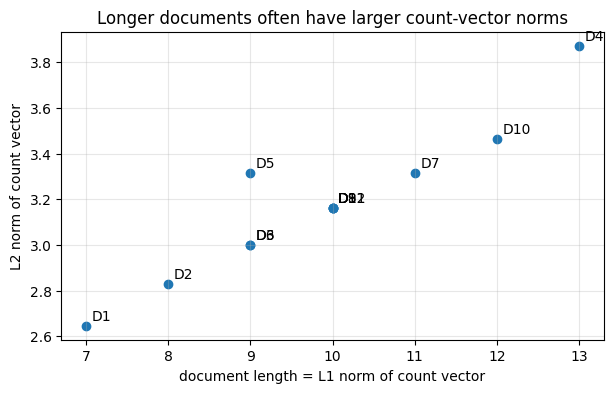

In [10]:
plt.figure(figsize=(7, 4))
plt.scatter(count_l1, count_l2)
for i, doc_id in enumerate(doc_ids):
    plt.annotate(doc_id, (count_l1[i], count_l2[i]), xytext=(4, 4), textcoords="offset points")
plt.xlabel("document length = L1 norm of count vector")
plt.ylabel("L2 norm of count vector")
plt.title("Longer documents often have larger count-vector norms")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Cosine similarity

For two nonzero vectors $x,y \in R^d$, the cosine similarity is

$$
\cos(x,y)=\frac{x \cdot y}{\|x\|_2\|y\|_2}.
$$

It measures the angle between vectors rather than their raw lengths.  This is why cosine similarity is widely used in text retrieval.

If vectors are normalized to unit length, then cosine similarity is just a dot product.

In [11]:
def l2_normalize_rows(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return np.divide(X, norms, out=np.zeros_like(X), where=norms != 0)

def cosine_scores(matrix, query_vector):
    X_norm = l2_normalize_rows(matrix)
    q_norm_value = np.linalg.norm(query_vector)
    if q_norm_value == 0:
        return np.zeros(matrix.shape[0])
    q_norm = query_vector / q_norm_value
    return X_norm @ q_norm

X_counts_l2 = l2_normalize_rows(X_counts)

# Pairwise cosine similarity between documents using count vectors.
pairwise_cosine = X_counts_l2 @ X_counts_l2.T
pd.DataFrame(pairwise_cosine, index=doc_ids, columns=doc_ids).round(3)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12
D1,1.000,0.000,0.000,0.195,0.114,0.000,0.000,0.120,0.000,0.000,0.000,0.120
D2,0.000,1.000,0.000,0.183,0.107,0.118,0.000,0.112,0.224,0.102,0.224,0.224
D3,0.000,0.000,1.000,0.000,0.201,0.111,0.201,0.105,0.105,0.096,0.105,0.105
D4,0.195,0.183,0.000,1.000,0.000,0.086,0.000,0.245,0.163,0.000,0.082,0.245
D5,0.114,0.107,0.201,0.000,1.000,0.000,0.000,0.000,0.000,0.261,0.000,0.000
D6,0.000,0.118,0.111,0.086,0.000,1.000,0.101,0.105,0.105,0.000,0.105,0.105
D7,0.000,0.000,0.201,0.000,0.000,0.101,1.000,0.095,0.000,0.261,0.191,0.000
D8,0.120,0.112,0.105,0.245,0.000,0.105,0.095,1.000,0.200,0.000,0.200,0.200
D9,0.000,0.224,0.105,0.163,0.000,0.105,0.000,0.200,1.000,0.000,0.100,0.100
D10,0.000,0.102,0.096,0.000,0.261,0.000,0.261,0.000,0.000,1.000,0.091,0.000


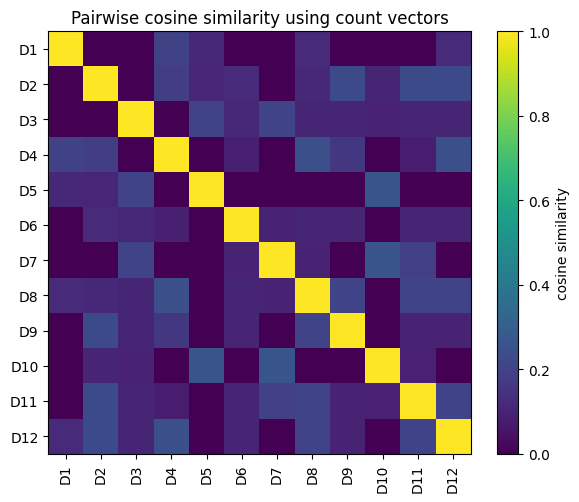

In [12]:
plt.figure(figsize=(6, 5))
plt.imshow(pairwise_cosine)
plt.colorbar(label="cosine similarity")
plt.xticks(range(len(doc_ids)), doc_ids, rotation=90)
plt.yticks(range(len(doc_ids)), doc_ids)
plt.title("Pairwise cosine similarity using count vectors")
plt.tight_layout()
plt.show()

## 11. Query vectors and count-based search

A query can be treated like a short document.  If a query vector is $q \in R^d$, count-based scores are

$$
s = Xq \in R^n.
$$

Cosine search first normalizes rows of $X$ and the query vector $q$, then computes one score per document.

In [13]:
def vectorize_query(query, vocab, representation="count"):
    tokens = tokenize(query)
    q = np.zeros(len(vocab), dtype=float)
    token_to_col = {token: j for j, token in enumerate(vocab)}
    for token in tokens:
        if token in token_to_col:
            q[token_to_col[token]] += 1
    if representation == "binary":
        q = (q > 0).astype(float)
    return q

def rank_documents(scores, top_k=5):
    order = np.argsort(-scores)
    rows = []
    for rank, i in enumerate(order[:top_k], start=1):
        rows.append({
            "rank": rank,
            "doc_id": doc_ids[i],
            "score": scores[i],
            "text": documents[i]
        })
    return pd.DataFrame(rows)

query = "vector similarity search"
q_count = vectorize_query(query, vocabulary)
count_cos_scores = cosine_scores(X_counts, q_count)

print("Query:", query)
rank_documents(count_cos_scores, top_k=6)

Query: vector similarity search


,rank,doc_id,score,text
0,1,D12,0.547723,A search engine uses vector similarity to find relevant text.
1,2,D2,0.204124,A document vector stores counts of vocabulary tokens.
2,3,D3,0.192450,Cosine similarity compares documents by the angle between vectors.
3,4,D11,0.182574,Embeddings map words or documents into a geometric vector space.
4,5,D5,0.000000,Probability models estimate the chance of the next word.
5,6,D6,0.000000,Optimization trains neural networks by minimizing a loss function.


### Try it yourself

Change the query to each of the following and compare results:

- `probability language model`
- `document matrix vector`
- `graph words documents`
- `optimization neural networks`
- `stop words information`

Which queries are easy for count vectors?  Which queries are ambiguous?

## 12. Document frequency and inverse document frequency

A term that appears in many documents may be less useful for distinguishing topics.  The **document frequency** of token $v_j$ is

$$
df_j=\#\{i:c_{ij}>0\}.
$$

A common smoothed inverse document frequency is

$$
idf_j = \log\left(\frac{1+n}{1+df_j}\right)+1.
$$

Rare terms get larger IDF values.  Common terms get smaller IDF values.

In [14]:
n = X_counts.shape[0]
df = np.count_nonzero(X_counts > 0, axis=0)
idf = np.log((1 + n) / (1 + df)) + 1

idf_table = pd.DataFrame({
    "token": vocabulary,
    "count": [token_counts[t] for t in vocabulary],
    "document_frequency": df,
    "idf": idf
}).sort_values(["idf", "token"], ascending=[False, True])

idf_table.head(20)

,token,count,document_frequency,idf
15,all,1,1,2.871802
16,angle,1,1,2.871802
17,are,1,1,2.871802
18,assign,1,1,2.871802
19,between,1,1,2.871802
20,can,1,1,2.871802
21,carry,1,1,2.871802
22,chance,1,1,2.871802
23,compares,1,1,2.871802
24,connected,1,1,2.871802


In [15]:
idf_table.sort_values("idf", ascending=True).head(20)

,token,count,document_frequency,idf
0,a,7,7,1.485508
2,documents,4,4,1.955511
1,to,5,4,1.955511
8,words,3,3,2.178655
6,of,3,3,2.178655
5,document,3,3,2.178655
4,by,3,3,2.178655
3,the,4,3,2.178655
7,vector,3,3,2.178655
9,and,2,2,2.466337


## 13. TF-IDF vectors

There are several versions of TF-IDF.  In this lab we use relative frequency for term frequency:

$$
tf_{ij}=\frac{c_{ij}}{\sum_{l=1}^d c_{il}}.
$$

Then

$$
tfidf_{ij}=tf_{ij} \cdot idf_j.
$$

Finally, we often normalize TF-IDF rows to unit length before cosine search.

In [16]:
X_tfidf = X_relative * idf
X_tfidf_l2 = l2_normalize_rows(X_tfidf)

# Show TF-IDF values for selected terms.
selected_terms = ["language", "models", "document", "vector", "similarity", "probability", "graph", "retrieval"]
selected_terms = [t for t in selected_terms if t in token_to_index]
selected_cols = [token_to_index[t] for t in selected_terms]

pd.DataFrame(X_tfidf[:, selected_cols], index=doc_ids, columns=selected_terms).round(3)

,language,models,document,vector,similarity,probability,graph,retrieval
D1,0.41,0.352,0.000,0.000,0.000,0.000,0.000,0.000
D2,0.00,0.000,0.272,0.272,0.000,0.000,0.000,0.000
D3,0.00,0.000,0.000,0.000,0.274,0.000,0.000,0.000
D4,0.00,0.000,0.168,0.000,0.000,0.000,0.000,0.000
D5,0.00,0.274,0.000,0.000,0.000,0.319,0.000,0.000
D6,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D7,0.00,0.000,0.000,0.000,0.000,0.000,0.261,0.000
D8,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.287
D9,0.00,0.000,0.218,0.000,0.000,0.000,0.000,0.000
D10,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## 14. TF-IDF search

To search with TF-IDF, we must transform the query using the same vocabulary and the same IDF weights.

This is important: the IDF weights are learned from the corpus.  A query should not recompute its own IDF values from itself.

In [17]:
def vectorize_query_tfidf(query, vocab, idf_values):
    q_counts = vectorize_query(query, vocab)
    total = q_counts.sum()
    if total == 0:
        return q_counts
    q_tf = q_counts / total
    return q_tf * idf_values

def search_count(query, top_k=5):
    q = vectorize_query(query, vocabulary)
    scores = cosine_scores(X_counts, q)
    return rank_documents(scores, top_k=top_k)

def search_tfidf(query, top_k=5):
    q = vectorize_query_tfidf(query, vocabulary, idf)
    scores = cosine_scores(X_tfidf, q)
    return rank_documents(scores, top_k=top_k)

query = "specific document vector similarity"
print("Count-vector search")
display(search_count(query, top_k=5))

print("TF-IDF search")
display(search_tfidf(query, top_k=5))

Count-vector search


,rank,doc_id,score,text
0,1,D2,0.353553,A document vector stores counts of vocabulary tokens.
1,2,D12,0.316228,A search engine uses vector similarity to find relevant text.
2,3,D4,0.258199,TF-IDF gives more weight to terms that are specific to a document.
3,4,D3,0.166667,Cosine similarity compares documents by the angle between vectors.
4,5,D9,0.158114,A matrix can store all document vectors in its rows.


TF-IDF search


,rank,doc_id,score,text
0,1,D2,0.276623,A document vector stores counts of vocabulary tokens.
1,2,D12,0.272398,A search engine uses vector similarity to find relevant text.
2,3,D4,0.271038,TF-IDF gives more weight to terms that are specific to a document.
3,4,D3,0.162979,Cosine similarity compares documents by the angle between vectors.
4,5,D11,0.120614,Embeddings map words or documents into a geometric vector space.


## 15. Compare count vectors and TF-IDF vectors

The following helper function prints two rankings side by side for the same query.

In [18]:
def compare_search(query, top_k=5):
    count_results = search_count(query, top_k=top_k)[["rank", "doc_id", "score"]].rename(columns={"score": "count_cosine"})
    tfidf_results = search_tfidf(query, top_k=top_k)[["rank", "doc_id", "score"]].rename(columns={"score": "tfidf_cosine"})
    print("Query:", query)
    print("\nCount-vector ranking")
    display(count_results)
    print("TF-IDF ranking")
    display(tfidf_results)

for q in [
    "language probability model",
    "document vector matrix",
    "search relevant text",
    "the of and document",
]:
    compare_search(q, top_k=5)
    print("-" * 70)

Query: language probability model

Count-vector ranking


,rank,doc_id,count_cosine
0,1,D1,0.267261
1,2,D5,0.213201
2,3,D3,0.000000
3,4,D2,0.000000
4,5,D4,0.000000


TF-IDF ranking


,rank,doc_id,tfidf_cosine
0,1,D1,0.283953
1,2,D5,0.240909
2,3,D3,0.000000
3,4,D2,0.000000
4,5,D4,0.000000


----------------------------------------------------------------------
Query: document vector matrix

Count-vector ranking


...

----------------------------------------------------------------------
Query: the of and document

Count-vector ranking


,rank,doc_id,count_cosine
0,1,D5,0.452267
1,2,D10,0.433013
2,3,D2,0.353553
3,4,D3,0.166667
4,5,D9,0.158114


TF-IDF ranking


,rank,doc_id,tfidf_cosine
0,1,D10,0.376681
1,2,D5,0.374734
2,3,D2,0.299502
3,4,D7,0.155842
4,5,D3,0.137694


----------------------------------------------------------------------


## 16. Stop words as coordinate projection

A stop word is a common word that is often removed before modeling.  Mathematically, removing a set of vocabulary coordinates is a projection.

Suppose $S$ is the set of stop-word coordinates.  Removing stop words means keeping only coordinates not in $S$.

This operation can improve topical search, but it is not neutral.  Some common words are important in particular tasks.  For example, negation words such as `not` and `never` may be essential for sentiment or safety-related text.

In [19]:
stop_words = {"a", "the", "of", "to", "and", "in", "as", "by", "that", "are", "or", "such"}
keep_indices = [j for j, token in enumerate(vocabulary) if token not in stop_words]
kept_vocabulary = [vocabulary[j] for j in keep_indices]

X_counts_no_stop = X_counts[:, keep_indices]
X_relative_no_stop = X_relative[:, keep_indices]

df_no_stop = np.count_nonzero(X_counts_no_stop > 0, axis=0)
idf_no_stop = np.log((1 + n) / (1 + df_no_stop)) + 1
X_tfidf_no_stop = X_relative_no_stop * idf_no_stop

print("Original vocabulary size:", len(vocabulary))
print("Vocabulary size after stop-word projection:", len(kept_vocabulary))
print("Removed tokens:", sorted(set(vocabulary).intersection(stop_words)))

Original vocabulary size: 86
Vocabulary size after stop-word projection: 74
Removed tokens: ['a', 'and', 'are', 'as', 'by', 'in', 'of', 'or', 'such', 'that', 'the', 'to']


In [20]:
def search_tfidf_no_stop(query, top_k=5):
    q = vectorize_query_tfidf(query, kept_vocabulary, idf_no_stop)
    scores = cosine_scores(X_tfidf_no_stop, q)
    return rank_documents(scores, top_k=top_k)

query = "the document of vector and matrix"
print("TF-IDF with all coordinates")
display(search_tfidf(query, top_k=5))

print("TF-IDF after stop-word projection")
display(search_tfidf_no_stop(query, top_k=5))

TF-IDF with all coordinates


,rank,doc_id,score,text
0,1,D2,0.350874,A document vector stores counts of vocabulary tokens.
1,2,D10,0.294194,Stop words such as the and of often carry little topical information.
2,3,D5,0.292673,Probability models estimate the chance of the next word.
3,4,D9,0.271793,A matrix can store all document vectors in its rows.
4,5,D7,0.121715,Graph methods represent words and documents as nodes connected by edges.


TF-IDF after stop-word projection


,rank,doc_id,score,text
0,1,D9,0.397237,A matrix can store all document vectors in its rows.
1,2,D2,0.345799,A document vector stores counts of vocabulary tokens.
2,3,D11,0.152576,Embeddings map words or documents into a geometric vector space.
3,4,D12,0.145108,A search engine uses vector similarity to find relevant text.
4,5,D4,0.142572,TF-IDF gives more weight to terms that are specific to a document.


## 17. Sparse geometry

Text vectors are often high-dimensional and sparse.  In this small corpus the vocabulary is modest, but most document vectors still have many zero coordinates.

The sparsity of a matrix can be measured by

$$
\text{sparsity}=1-\frac{\#\text{nonzero entries}}{nd}.
$$

A sparsity value near $1$ means most entries are zero.

In [21]:
def matrix_sparsity(X):
    return 1 - np.count_nonzero(X) / X.size

sparsity_table = pd.DataFrame({
    "matrix": ["count", "binary", "relative_frequency", "tfidf"],
    "shape": [str(X_counts.shape), str(X_binary.shape), str(X_relative.shape), str(X_tfidf.shape)],
    "nonzero_entries": [np.count_nonzero(M) for M in [X_counts, X_binary, X_relative, X_tfidf]],
    "sparsity": [matrix_sparsity(M) for M in [X_counts, X_binary, X_relative, X_tfidf]]
})
sparsity_table

,matrix,shape,nonzero_entries,sparsity
0,count,"(12, 86)",116,0.887597
1,binary,"(12, 86)",116,0.887597
2,relative_frequency,"(12, 86)",116,0.887597
3,tfidf,"(12, 86)",116,0.887597


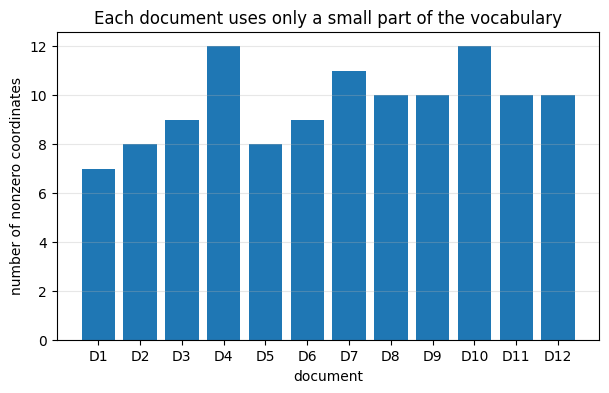

In [22]:
nonzeros_per_doc = np.count_nonzero(X_counts, axis=1)

plt.figure(figsize=(7, 4))
plt.bar(doc_ids, nonzeros_per_doc)
plt.xlabel("document")
plt.ylabel("number of nonzero coordinates")
plt.title("Each document uses only a small part of the vocabulary")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 18. Low-dimensional visualization using SVD

TF-IDF vectors live in $R^d$, which is difficult to visualize when $d$ is large.  Singular value decomposition gives a simple way to project the document matrix into two dimensions.

For a matrix $A$, SVD gives

$$
A = U \Sigma V^T.
$$

The first two columns of $U\Sigma$ provide a two-dimensional coordinate system that captures the largest directions of variation in the matrix.

This is not the same as modern neural embedding, but it is an important classical idea behind latent semantic analysis.

In [23]:
# Center columns before SVD for visualization.
A = X_tfidf_l2 - X_tfidf_l2.mean(axis=0, keepdims=True)
U, singular_values, Vt = np.linalg.svd(A, full_matrices=False)
coords = U[:, :2] * singular_values[:2]

svd_table = pd.DataFrame({
    "doc_id": doc_ids,
    "component_1": coords[:, 0],
    "component_2": coords[:, 1],
    "text": documents
})
svd_table.round(3)

,doc_id,component_1,component_2,text
0,D1,-0.175,0.586,Language models assign probabilities to token sequences.
1,D2,-0.179,-0.014,A document vector stores counts of vocabulary tokens.
2,D3,0.264,-0.078,Cosine similarity compares documents by the angle between vectors.
3,D4,-0.453,0.170,TF-IDF gives more weight to terms that are specific to a document.
4,D5,0.372,0.586,Probability models estimate the chance of the next word.
5,D6,0.011,-0.266,Optimization trains neural networks by minimizing a loss function.
6,D7,0.471,-0.356,Graph methods represent words and documents as nodes connected by edges.
7,D8,-0.309,-0.140,Retrieval systems rank documents in response to a user query.
8,D9,-0.272,-0.153,A matrix can store all document vectors in its rows.
9,D10,0.576,0.105,Stop words such as the and of often carry little topical information.


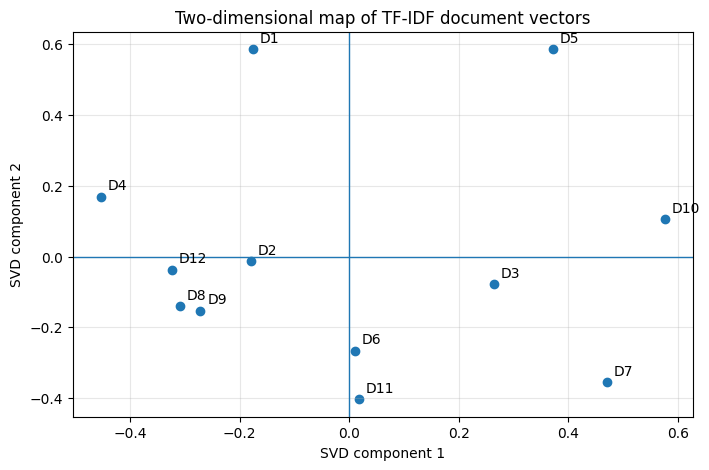

D1: Language models assign probabilities to token sequences.
D2: A document vector stores counts of vocabulary tokens.
D3: Cosine similarity compares documents by the angle between vectors.
D4: TF-IDF gives more weight to terms that are specific to a document.
D5: Probability models estimate the chance of the next word.
D6: Optimization trains neural networks by minimizing a loss function.
D7: Graph methods represent words and documents as nodes connected by edges.
D8: Retrieval systems rank documents in response to a user query.
D9: A matrix can store all document vectors in its rows.
D10: Stop words such as the and of often carry little topical information.
D11: Embeddings map words or documents into a geometric vector space.
D12: A search engine uses vector similarity to find relevant text.


In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(coords[:, 0], coords[:, 1])
for i, doc_id in enumerate(doc_ids):
    plt.annotate(doc_id, (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords="offset points")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("Two-dimensional map of TF-IDF document vectors")
plt.grid(True, alpha=0.3)
plt.show()

for i, doc in enumerate(documents):
    print(f"{doc_ids[i]}: {doc}")

## 19. Retrieval evaluation: precision at k

A search ranking should be evaluated.  For a query, suppose we know a set of relevant documents $R$.  If the top $k$ returned documents are $A_k$, then

$$
\text{precision at }k = \frac{|A_k \cap R|}{k}.
$$

This is a tiny educational evaluation.  In real systems, relevance judgments are expensive and evaluation requires careful design.

In [25]:
relevance = {
    "document vector matrix": {"D2", "D3", "D8", "D9", "D12"},
    "language probability model": {"D1", "D5"},
    "graph words documents": {"D7", "D11"},
    "optimization neural networks": {"D6"},
    "stop words information": {"D10"},
}

def precision_at_k(result_table, relevant_set, k):
    retrieved = set(result_table.head(k)["doc_id"])
    return len(retrieved.intersection(relevant_set)) / k

rows = []
for q, relevant_docs in relevance.items():
    count_result = search_count(q, top_k=5)
    tfidf_result = search_tfidf(q, top_k=5)
    rows.append({
        "query": q,
        "model": "count cosine",
        "precision@3": precision_at_k(count_result, relevant_docs, 3),
        "top3": ", ".join(count_result.head(3)["doc_id"])
    })
    rows.append({
        "query": q,
        "model": "tfidf cosine",
        "precision@3": precision_at_k(tfidf_result, relevant_docs, 3),
        "top3": ", ".join(tfidf_result.head(3)["doc_id"])
    })

eval_table = pd.DataFrame(rows)
eval_table

,query,model,precision@3,top3
0,document vector matrix,count cosine,0.666667,"D2, D9, D11"
1,document vector matrix,tfidf cosine,0.666667,"D9, D2, D11"
2,language probability model,count cosine,0.666667,"D1, D5, D3"
3,language probability model,tfidf cosine,0.666667,"D1, D5, D3"
4,graph words documents,count cosine,0.666667,"D7, D11, D3"
5,graph words documents,tfidf cosine,0.666667,"D7, D11, D10"
6,optimization neural networks,count cosine,0.333333,"D6, D1, D3"
7,optimization neural networks,tfidf cosine,0.333333,"D6, D1, D3"
8,stop words information,count cosine,0.333333,"D10, D11, D7"
9,stop words information,tfidf cosine,0.333333,"D10, D11, D7"


## 20. What bag-of-words preserves and loses

The document vectors in this lab are **bag-of-words** representations.  They preserve:

- which vocabulary terms occur;
- how often terms occur;
- rough topical overlap between documents;
- sparse vector geometry useful for search.

They lose:

- word order;
- syntax;
- many meanings of negation and phrase structure;
- contextual meaning;
- the difference between some sentences with the same words.

For example, the two sentences below have the same count vector under a basic bag-of-words tokenizer:

1. `the model beats the baseline`
2. `the baseline beats the model`

Their meanings are different, but their count vectors are identical.

In [26]:
s1 = "the model beats the baseline"
s2 = "the baseline beats the model"
small_docs = [tokenize(s1), tokenize(s2)]
small_vocab = sorted(set(token for doc in small_docs for token in doc))
small_X = build_count_matrix(small_docs, small_vocab)

print("Vocabulary:", small_vocab)
print("Sentence 1 tokens:", small_docs[0])
print("Sentence 2 tokens:", small_docs[1])
display(pd.DataFrame(small_X, index=["s1", "s2"], columns=small_vocab))
print("Are the count vectors equal?", np.array_equal(small_X[0], small_X[1]))

Vocabulary: ['baseline', 'beats', 'model', 'the']
Sentence 1 tokens: ['the', 'model', 'beats', 'the', 'baseline']
Sentence 2 tokens: ['the', 'baseline', 'beats', 'the', 'model']


,baseline,beats,model,the
s1,1.0,1.0,1.0,2.0
s2,1.0,1.0,1.0,2.0


Are the count vectors equal? True


## 21. AI component: document vectors in retrieval-augmented generation

A retrieval-augmented generation system often has two parts:

$$
\text{query} \longrightarrow \text{retriever} \longrightarrow \text{context documents} \longrightarrow \text{generator}.
$$

The retriever uses a representation of documents and queries.  Classical systems may use TF-IDF or BM25.  Modern systems often use dense neural embeddings.  The mathematical idea is similar: represent text as vectors and rank documents by a similarity score.

When using AI tools to study document vectors, ask questions such as:

- Which preprocessing choices define the vocabulary?
- Are documents represented by counts, TF-IDF, or dense embeddings?
- Which similarity measure is being used?
- Are long documents unfairly favored?
- Are stop words, negations, or domain-specific terms handled correctly?
- How is retrieval quality evaluated?

## 22. Exercises

### Exercise 1: Hand calculation

Use the vocabulary

$$
V = (\text{data}, \text{model}, \text{vector})
$$

and the documents

$$
x_1=(\text{data},\text{model},\text{model}),
$$

$$
x_2=(\text{vector},\text{model}),
$$

$$
x_3=(\text{data},\text{vector},\text{vector}).
$$

1. Write the count matrix $X$.
2. Write the binary matrix.
3. Compute the relative-frequency matrix.
4. Compute the cosine similarity between $x_1$ and $x_2$ using count vectors.

### Exercise 2: Query search

Add three documents about a topic of your choice.  Rebuild the vocabulary and document-term matrix.  Then run at least three queries.  Record which queries work well and which do not.

### Exercise 3: Stop-word projection

Modify the stop-word list.  Add `model`, `document`, or `vector` to the stop-word list.  What changes?  Why might removing domain-specific words be harmful?

### Exercise 4: TF-IDF interpretation

Find the five tokens with the largest IDF values in this corpus.  Are they genuinely important?  Are they rare because the corpus is small?

### Exercise 5: Geometry

Use the pairwise cosine matrix to find two documents that are most similar and two documents that are least similar.  Does the result match your intuition?

## 23. Mini-project: build a small mathematical search engine

Create a search engine for a small set of notes, definitions, or course descriptions.

Your project should include:

1. at least 15 short documents;
2. a tokenizer;
3. a vocabulary;
4. a document-term matrix;
5. TF-IDF vectors;
6. cosine search;
7. at least five test queries;
8. a small relevance table;
9. precision at $3$ for each query;
10. a short written reflection.

In your reflection, answer:

- Which queries worked best?
- Which queries failed?
- Did TF-IDF improve over count vectors?
- What information was lost by bag-of-words?
- What would a neural embedding model improve?

## 24. Lab summary

In this lab, we built the classical vector-space model of text from scratch.

Key mathematical objects:

$$
\phi:V^* \to R^d,
$$

$$
X \in R^{n \times d},
$$

$$
\cos(x,y)=\frac{x\cdot y}{\|x\|_2\|y\|_2},
$$

$$
idf_j = \log\left(\frac{1+n}{1+df_j}\right)+1,
$$

$$
tfidf_{ij}=tf_{ij}idf_j.
$$

The main lesson is that text representation is a mathematical modeling choice.  Count vectors, TF-IDF vectors, and embeddings each encode different assumptions about what information matters.